# M-PESA FRAUD DETECTION

In Kenya, the fintech industry in money transactions is primarily dominated by mobile money — **M-Pesa** to be exact.

Launched in 2007, M-Pesa tackled a systemic and infrastructural gap the African banking system couldn't close. While banking institutions adopted Western-developed infrastructure architectures, the majority of Kenyans were left with limited access to financial services — banks only had branches in major towns and cities. M-Pesa changed this entirely: all you needed was a SIM card. With agents operating in deep rural areas across the country, money could reach the most remote corners of Kenya within seconds, compared to money orders that could take over three days.

Today, Kenya's economy is built around M-Pesa. It is embedded in transactions as low as KSh 1 — across SMEs, small local shops, kiosks, mobile-to-bank transfers, and everyday essentials like buying airtime, paying for fare, or sending money to *mama mboga*.

> **Dataset Disclaimer:** This notebook uses a synthetic M-Pesa fraud dataset that mimics real transaction behaviour across different categorical variables. See the **Dataset** section for scope and limitations.

## PROBLEM STATEMENT

As M-Pesa came to dominate money transactions in Kenya, so did the volume of fraudulent activity targeting its users. Common attack vectors include **SIM swaps**, **social engineering**, and **fraudulent merchant transactions**. Fraudsters continuously adapt their tactics — deploying number masking, fake balance SMS traps, and agent impersonation to exploit both everyday users and M-Pesa agents.

### The Scale of the Problem

Safaricom's FY2024 Annual Report places the total value of M-Pesa transactions at **KSh 38.29 trillion annually**, representing **37.15 billion individual transactions** over a 12-month period — making M-Pesa the largest fintech platform on the African continent.

TransUnion's H2 2024 Consumer Pulse Study reports that the median loss per successful digital scam in Kenya is **KSh 108,132** — the highest median financial loss recorded among all African countries surveyed.

Applying a conservative network fraud rate of **0.006%** to Safaricom's reported transaction volume yields a systemic annual loss estimate of **KSh 2.30 billion (~$17.6 million USD)**.

### Mathematical Breakdown

| Metric | Value |
|---|---|
| Total Transaction Value | KSh 38,290,000,000,000 |
| Estimated Network Fraud Rate | 0.006% |
| Annual Systemic Loss | KSh 2,297,400,000 |

### Putting the Losses in Context

- **Daily drainage:** ~KSh 6.30 million stolen from the ecosystem every single day
- **Hourly theft:** ~KSh 262,260 lost to fraud networks every hour
- **Individual impact:** At the TransUnion median loss of KSh 108,132, this figure represents roughly **21,246 successful scam operations** hitting Kenyan users annually

### Why This Is a Conservative Floor

The KSh 2.3 billion estimate captures direct systemic loss — actual socioeconomic damage is likely significantly higher:

- **Underreporting:** A large proportion of P2P fraud victims do not report losses under KSh 5,000 to Safaricom or law enforcement, either out of embarrassment or a belief that recovery is unlikely
- **Secondary losses:** The estimate does not capture funds stolen from bank accounts linked to M-Pesa via mobile banking integrations
- **Collateral business damage:** For small merchants, fraud-related losses frequently lead to business closure, credit score damage, or legal costs that never appear in network transaction data

## GOAL

With fraudulent transactions costing the Kenyan economy billions annually, this project builds an **end-to-end machine learning pipeline** that classifies whether a transaction should be flagged as fraudulent — in real time, within the latency window of an M-Pesa transaction initiation.

Rather than logging fraud after the fact, this pipeline is designed to **intercept transactions before settlement**. The model sits between transaction initiation and transaction completion, returning one of three decisions:

| Decision | Condition |
|---|---|
| `ALLOW` | Transaction meets no fraud threshold — proceed normally |
| `CHALLENGE` | Transaction exhibits elevated risk — trigger OTP or user verification |
| `BLOCK` | Transaction meets fraud threshold — halt before settlement |

This positions the model not as a detection audit tool, but as a **real-time transaction decisioning engine** — one that protects customers before money leaves their account, and helps platforms like M-Pesa strengthen the trust that underpins their entire value proposition.

## DATASET

**Source:** Synthetic M-Pesa Fraud Dataset — [Kaggle (calebboen)](https://www.kaggle.com/datasets/calebboen/mpesa-transactions-fraud)  
**Size:** 120,000 transactions × 13 features  
**Target variable:** `is_fraud` (binary: 0 = legitimate, 1 = fraudulent)  
**Overall fraud rate:** ~2.93% (3,510 fraudulent transactions)

### Features

| Feature | Type | Description |
|---|---|---|
| `transaction_id` | string | Unique transaction identifier |
| `amount` | float | Transaction amount (KSh) |
| `sender_balance_before` | float | Sender wallet balance before transaction |
| `sender_balance_after` | float | Sender wallet balance after transaction |
| `receiver_balance_before` | float | Receiver wallet balance before transaction |
| `receiver_balance_after` | float | Receiver wallet balance after transaction |
| `transaction_type` | categorical | peer / till / paybill |
| `hour` | int | Hour of transaction (0–23) |
| `month_2026` | int | Month of transaction |
| `day_of_week` | categorical | Day name (Mon–Sun) |
| `device_type` | categorical | feature / smartphone |
| `region` | categorical | Nairobi / Mombasa / Kisumu / Nakuru / Eldoret |
| `is_fraud` | int | Target label (0 or 1) |

### Known Limitations

- **Uniform fraud distribution:** Fraud rates are nearly identical across all categorical variables (~2.9% per slice). Real-world fraud patterns exhibit strong variation — e.g., higher rates on feature phones (SIM swap vector) and overnight transactions. This is a known characteristic of synthetic data and is addressed in the EDA.
- **Inflated fraud rate:** The dataset's 2.93% fraud rate is approximately 490× higher than Safaricom's estimated network fraud rate of 0.006%. This is intentional for model training — sufficient fraud examples are required for the classifier to learn — but should not be interpreted as a realistic prevalence estimate.
- **No agent transaction type:** M-Pesa agent float abuse is a documented fraud vector not represented in this dataset.
- **No SIM swap flag:** SIM swap fraud — one of the most damaging attack types — is not explicitly labelled as a transaction subtype.

These limitations are documented in the model card and inform the scope of future work.

## DELIVERABLES

1. **EDA notebook** — exploratory analysis with business insights, fraud pattern visualisations, and feature distribution analysis
2. **Feature engineering** — balance drain ratio, cyclical time encoding, and derived behavioural features documented with rationale
3. **End-to-end ML pipeline** — data ingestion → preprocessing → feature engineering → model training → evaluation
4. **Class imbalance handling** — SMOTE oversampling and cost-sensitive learning, with comparison of impact on model performance
5. **Model comparison** — Logistic Regression, Random Forest, XGBoost, LightGBM evaluated on precision, recall, F1, and AUC-ROC
6. **FastAPI decisioning endpoint** — real-time transaction scoring returning fraud probability, risk tier, recommended action (`ALLOW/CHALLENGE/BLOCK`), and action rationale
7. **Model card** — performance metrics, feature importance, known biases, dataset limitations, and future expansion scope

In [1]:
# Library Importations
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


In [2]:
# Loading data to memory
data = pd.read_csv('../Data/mpesa_synthetic.csv')
data.head()

,transaction_id,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,transaction_type,hour,month_2026,day_of_week,device_type,region,is_fraud
0,UA0IFD0TV,703.90,58586.32,57882.42,29932.92,30636.82,peer,14,1,Tuesday,smartphone,Nairobi,0
1,UJAHXTHV3,254.44,8088.00,7833.56,22962.44,23216.88,peer,18,10,Saturday,feature,Eldoret,1
2,UEF8MDD4V,609.04,56675.00,56065.96,1029.22,1638.26,till,7,5,Thursday,smartphone,Kisumu,0
3,UBT3W5UZB,5255.34,75090.36,69835.02,38.94,5294.28,paybill,11,2,Monday,smartphone,Nakuru,0
4,UGKWNNHJ7,7282.67,24408.96,17126.29,26237.82,33520.49,till,0,7,Saturday,smartphone,Nairobi,0


In [3]:
# Data overview
print(f"{'='*100}\nTotal Null Values per Column: {data.isna().sum()}")
print(f"{'='*100}\nData Shape: {data.shape}")
print('='*100)
print(f"{'='*100}\nData infomation including data types: \n{data.info()}")
print(f"{'='*100}\nStatistical Overview: \n{data.describe()}")
print(f"{'='*100}\nColumns:\n{data.columns}")

Total Null Values per Column: transaction_id             0
amount                     0
sender_balance_before      0
sender_balance_after       0
receiver_balance_before    0
receiver_balance_after     0
transaction_type           0
hour                       0
month_2026                 0
day_of_week                0
device_type                0
region                     0
is_fraud                   0
dtype: int64
Data Shape: (120000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           120000 non-null  str    
 1   amount                   120000 non-null  float64
 2   sender_balance_before    120000 non-null  float64
 3   sender_balance_after     120000 non-null  float64
 4   receiver_balance_before  120000 non-null  float64
 5   receiver_balance_after   120000 non-null  float64
 6   transactio

In [4]:
corr_data = data.drop(columns = ['transaction_id'])
matrix = corr_data.corr(numeric_only=True)
matrix

,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,hour,month_2026,is_fraud
amount,1.000000,0.001831,-0.061490,-0.002718,0.101417,0.001920,-0.000120,0.118114
sender_balance_before,0.001831,1.000000,0.997927,-0.000347,-0.000155,0.000023,0.004741,-0.192841
sender_balance_after,-0.061490,0.997927,1.000000,-0.000143,-0.006545,-0.000059,0.004684,-0.194095
receiver_balance_before,-0.002718,-0.000347,-0.000143,1.000000,0.994565,0.005184,0.002821,0.003664
receiver_balance_after,0.101417,-0.000155,-0.006545,0.994565,1.000000,0.005357,0.002794,0.015943
hour,0.001920,0.000023,-0.000059,0.005184,0.005357,1.000000,0.002638,0.002875
month_2026,-0.000120,0.004741,0.004684,0.002821,0.002794,0.002638,1.000000,-0.003288
is_fraud,0.118114,-0.192841,-0.194095,0.003664,0.015943,0.002875,-0.003288,1.000000


In [5]:
# Finding the total amount transacted(in this data set)
total = data['amount'].sum()
print(total)

180814913.21


> - The total amount transacted in this data set was **180,814,913.21**

##### Transactions through diffrent categories

- ##### Transactions grouped monthly

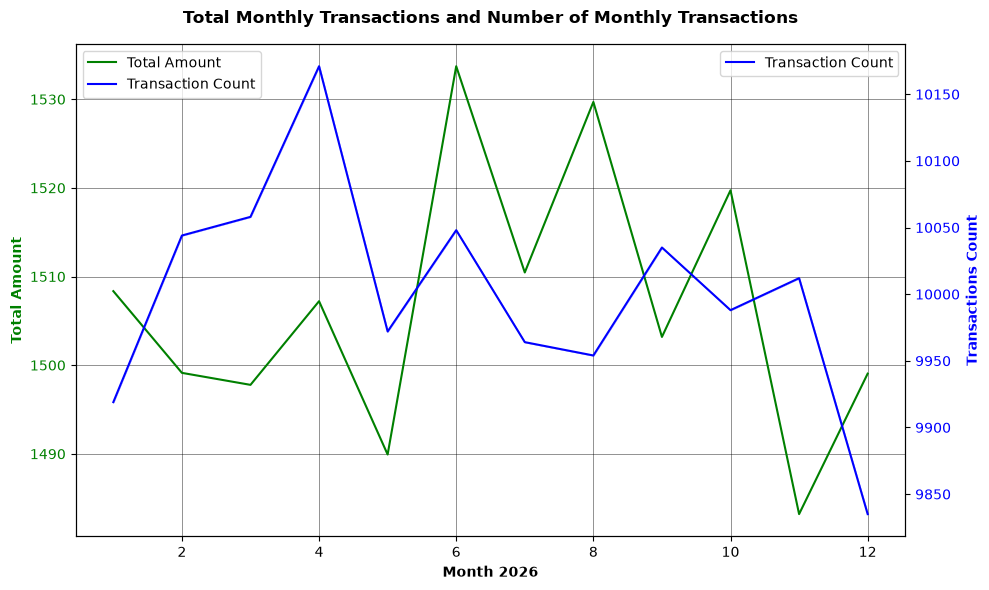

In [6]:
# Aggregated monthly data
monthly_total_trans = data.groupby('month_2026')['amount'].mean().reset_index()

# 1. Create canvas and first axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# 2. Plot Total Amount (Added 'label' argument)
sns.lineplot(data=monthly_total_trans, x='month_2026', y='amount', ax=ax1, color='green', label='Total Amount')
ax1.set_ylabel('Total Amount', color='green', weight='bold')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Month 2026', weight='bold')

# 3. Create twin axis
ax2 = ax1.twinx()

# 4. Plot Transaction Count (Added 'label' argument)
sns.lineplot(data=data, x='month_2026', y='month_2026', estimator=len, ax=ax2, color='blue', label='Transaction Count')
ax2.set_ylabel('Transactions Count', color='blue', weight='bold')
ax2.tick_params(axis='y', labelcolor='blue')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Combine them into one single legend box on ax1
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# 5. Global styling
plt.title('Total Monthly Transactions and Number of Monthly Transactions', weight='bold', pad=15)
ax1.grid(True, color='black', linewidth=0.5, alpha=0.6)  
fig.tight_layout()  
plt.show()


- ##### Boxplot to visualize the statistical distribution in amount

In [7]:
# Plotly interactive boxplot
fig = px.box(data, x='is_fraud', y="amount",
             color='is_fraud',
             title='STATISTICAL DISTRIBUTION OF TRANSACTION AMOUNT')
fig.show()
fig.write_image("../Reports/boxplot.png")

### TRANSACTION ANALYSIS

To get a better understanding of the transactions in our data set I set out to answer the following questions:
1. How balanced is the dataset between legitimate and fraudulent transactions?
2. How are transaction amounts distributed across the dataset?
3. How does sender account balance look before a transaction is initiated?
4. At what hours of the day do M-Pesa transactions peak?
5. Which days of the week see the highest transaction volumes?
6. Which months contributed to more transactions?
7. How are transactions distributed across regions and transaction types?
8. Does device type influence transaction volume?

I created a PowerBI dashboard to answer the questions above and this are the insights I got from my analysis:

#### How balanced is the dataset between legitimate and fraudulent transactions?
The data showed high imbalance which is consistent with real-world fraud prevalence, where fraud represents a small minority of total transactions.

The the classes were as follows:
- **NOT FRAUD(0)** : 116,490(97.08%) transactions
- **FRAUD(1)** : 3,510(2.93%) transactions

#### How are transaction amounts distributed across the dataset?
This shows that transaction amounts are right-skewed, with the majority of transactions falling between **KSh 0–2,000**. A small number of high-value outliers extend the distribution to a **maximum of KSh 18,750**.

#### How does sender and receiver account balance look before a transaction is initiated?
For this I looked at the measures of central tendancies to have a clear look on both categories the findings were as follows:

|| Sender Balance Before | Receiver Balance Before |
|---|---|---|
| `MEAN` | 40,050 | 24,960 |
| `MEDIAN` | 40,170 | 24,990 |
| `MODE` | 3,260 | 5,210 |

The closeness of mean and median for both groups suggests balance distributions are relatively symmetric without extreme outliers.

Even though senders had more balance compaired to receivers in totality(almost double), the majority of receivers had more balance in their accounts before a transaction than the the majority of the senders - 5,210 vs 3,260

#### At what hours of the day do M-Pesa transactions peak?
In our data set the peak hour occured at hour 4 - 4.00 AM with a transaction count of **5151** transactions throughout the year and leading to a total of **KES 7,889,442.79** transacted.
> Note: A 4AM peak is inconsistent with real-world M-Pesa usage patterns and is an artefact of the synthetic data generation process." That shows critical awareness.

The hour with the least number of transactions was hour **23(11.00 PM)** with **4,849** transactions, but the hour with the smallest total amount transacted was hour **8 (8.00 AM) - KES 7,216,194.34,** despite it having **4,960 transactions - 111 more transactions** than hour 23, meaning that transactions that are made during hour 8 are generaly low amount transactions.

#### Which days of the week see the highest transaction volumes?
Monday had both the highest volume of transactions and amount transacted sitting at **17,408 transactions totaling to KES 26,279,299.09**.

Thursday had the least number of transactions with **16,822** transactions but Wednesday saw the least amount of money transacted with **KES 25,363,977.72**

#### Which months contributed to more transactions?
The month of **April** saw the highest transactions in the year- **10171 transaction** but **June** had the most amount of money transacted - **KES 15,410,856.70**.

**December** was the month with the least amount transacted and number of transactions with **9,835 transactions totaling to KES 14,743,131.78**
> NOTE: December is typically high M-Pesa activity in Kenya (festive season, travel, remittances).


> For questions 7 and 8 transaction distribution across regions, transaction types, and device types is near-uniform, consistent with the synthetic nature of the dataset

### Key Takeaways
The dataset reflects a heavily imbalanced, right-skewed transaction environment typical of mobile money ecosystems. 
Transaction behaviour is broadly uniform across categorical variables — region, type, and device — a characteristic 
of the synthetic generation process that will inform our approach to feature engineering in the next section.

> The analysis dashboard snip is show in the next cell bellow

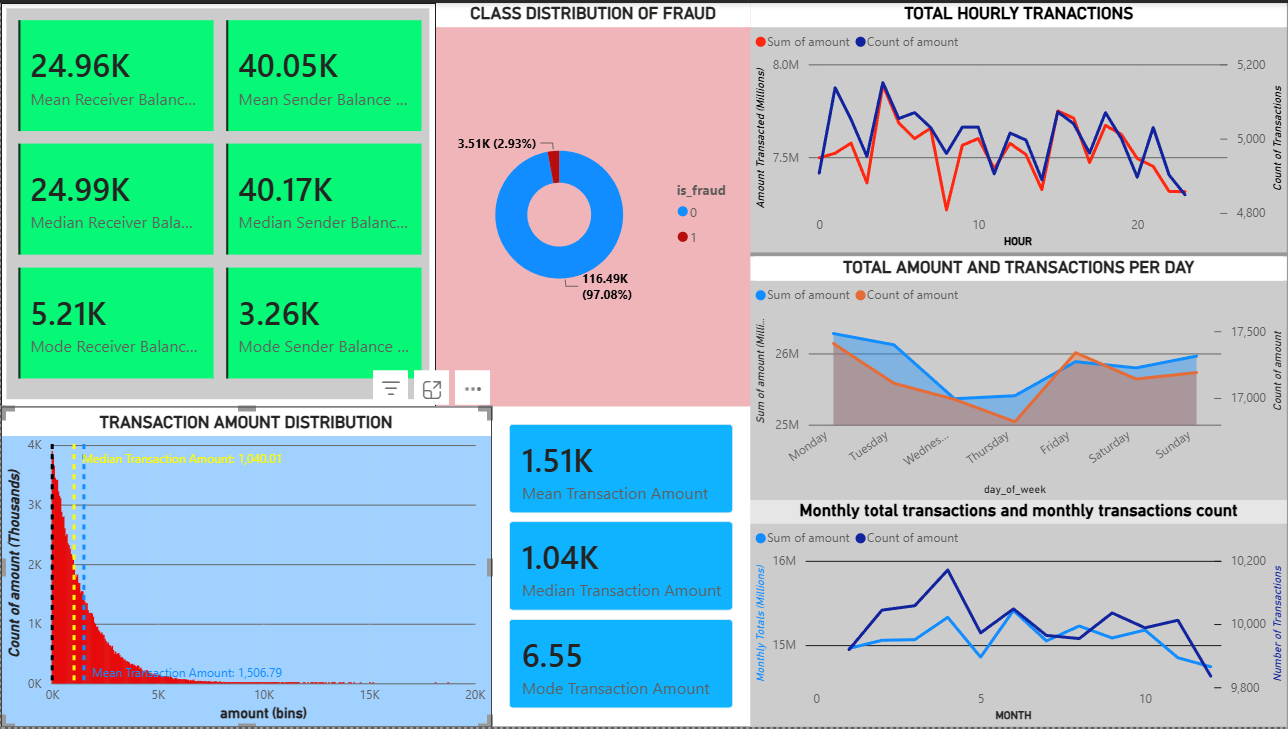

In [5]:
# Displaying the Transaction analysis of the powerBI report.
from IPython.display import Image
Image('../Reports/transactions.png')

### FRAUD ANALYSIS